In [34]:
import numpy as np
import matplotlib.pyplot as plt
from cd.algs.cd_poly import CDPolynomial

In [35]:
from cd.algs.window_ds import WindowDataset
from torch.utils.data import DataLoader
from conv_seq_ae import ConvSeqAutoencoder
import lightning as L
import torch

In [36]:
npz = np.load('humanoid/test.npz')
s = npz['states']
fail = npz['fail']
fail_ep = fail > 0

In [37]:
W = 50
STRIDE = 10
ds = WindowDataset(s, fail, past_win=W, fut_win=10, stride=STRIDE)
dl = DataLoader(ds, batch_size=128, shuffle=False)
model = ConvSeqAutoencoder.load_from_checkpoint('humanoid/conv/lightning_logs/version_31/checkpoints/epoch=9-step=7500.ckpt')
#model = ConvSeqAutoencoder.load_from_checkpoint('humanoid/conv/lightning_logs/version_14/checkpoints/epoch=9-step=7500.ckpt')
model.eval()

ConvSeqAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(348, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (7): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (fc_enc): Linear(in_features=112, out_features=16, bias=True)
  (fc_decode): Linear(in_features=16, out_features=112, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (4)

In [38]:
fail_mask_win = np.repeat(fail, 96)

In [39]:
fail_mask_win = []
for step in fail:
    if step == 0:
        fails = np.zeros(96, dtype=bool)
    else:
        win_idx = (step - 50) // 10 # last window to end before step
        fails = np.zeros(96, dtype=bool)
        fails[win_idx+1:] = True
    fail_mask_win.append(fails)
fail_mask_win = np.concatenate(fail_mask_win)

In [40]:
len(fail_mask_win)

96000

In [41]:
lat = []
fail_win = []
for xb, yb in dl:
    with torch.no_grad():
        zb = model.forward(xb.to(model.device))[1].cpu().numpy()
    lat.append(zb)
    fail_win.append(yb)
lat = np.concatenate(lat)
fail_win = np.concatenate(fail_win)

In [42]:
lat.shape, fail_win.shape

((95000, 16), (95000,))

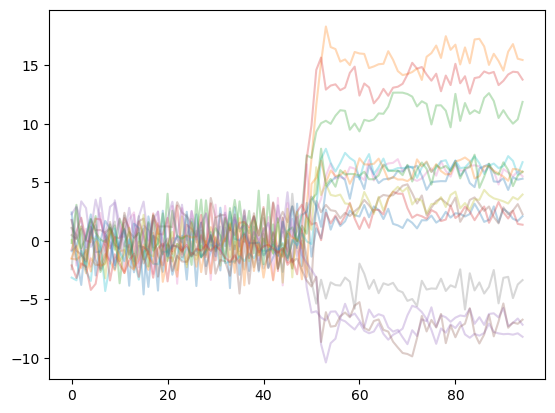

In [45]:
plt.plot(lat.reshape((1000, ds.windows_per_ep, 16))[1], alpha=0.3);

In [46]:
p = CDPolynomial(lat[~fail_win], degree=2, verbose=True)

Data monomials shape: torch.Size([73076, 153])
Moment matrix cond num: 5.685810e+04
Empirical mean of CD poly: 153.00001525878906


Text(0.5, 1.0, 'Distibution of CD polynomial values with contrastive loss')

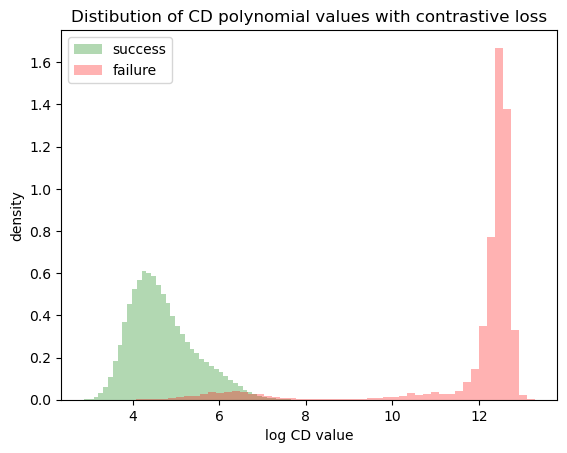

In [48]:
plt.hist(np.log(p(lat[~fail_win])), alpha=.3, color='green', density=True, bins=50, label='success')
plt.hist(np.log(p(lat[fail_win])), alpha=.3, color='red', density=True, bins=50, label='failure')
plt.xlabel('log CD value')
plt.ylabel('density')
plt.legend()
plt.title('Distibution of CD polynomial values with contrastive loss')